In [1]:
"""
Rigorous Verification of MBAR (DimRedPy vs pymbar)

This script validates that the DimRedPy framework produces mathematically identical 
free-energy surfaces and statistical weights to the underlying pymbar reference implementation.
We utilize rigorous statistical metrics on the final Free Energy Surfaces (FES) and MBAR weights:
1. Mean Squared Error (MSE)
2. Pearson Correlation (R)
"""

import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from scipy.stats import pearsonr

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import pymbar
from dimredpy.mbar import mbar_free_energy_surface

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

********* JAX NOT FOUND *********
 PyMBAR can run faster with JAX  
 But will work fine without it   
Either install with pip or conda:
      pip install pybar[jax]     
               OR                
      conda install pymbar       
*********************************


In [2]:
# ---------------------------------------------------------------------------
# 1. Generate Synthetic Replica-Exchange Data
# ---------------------------------------------------------------------------
# We create synthetic potential energies and collective variables (CVs) for 3 temperatures, 
# with 10,000 frames each to match the rigor of the other verifications.

np.random.seed(42)
K = 3  # 3 temperatures
N = 10000  # 10000 frames each
energies = np.random.randn(K * N) * 0.1
cvs = np.random.randn(K * N, 2)
temps = np.array([300.0, 350.0, 400.0])

print(f"Temperatures: {temps}")
print(f"Total samples: {K * N}")

Temperatures: [300. 350. 400.]
Total samples: 30000


In [3]:
# ---------------------------------------------------------------------------
# 2. Run Reference Framework (pymbar directly)
# ---------------------------------------------------------------------------
# We manually construct the reduced potential matrix u_kn and run pymbar,
# then manually construct the 2D probability surface.

print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (pymbar)")
print("=======================================================")

kB_CONST = 8.617333262e-5 # Exact constant used in dimredpy
beta_k = 1.0 / (kB_CONST * temps)

# Number of samples per state
N_k = np.array([N] * K)

# Build U_kn matrix
U_kn = np.zeros((K, K * N))
for k in range(K):
    U_kn[k, :] = energies * beta_k[k]

# Run MBAR
mbar_ref = pymbar.MBAR(U_kn, N_k)
weights_ref = mbar_ref.W_nk.T  # (K, N_total)

# Build probability surface for the first temperature (300K)
w_300K_ref = weights_ref[0] / weights_ref[0].sum()
prob_ref, x_edges, y_edges = np.histogram2d(
    cvs[:, 0], cvs[:, 1], bins=50, weights=w_300K_ref
)
prob_ref = prob_ref / prob_ref.sum()

# Convert probability to free energy
with np.errstate(divide='ignore', invalid='ignore'):
    fe_ref = -np.log(np.where(prob_ref > 0, prob_ref, np.nan))
    fe_ref -= np.nanmin(fe_ref)

print("-> Reference execution finished.")


          RUNNING REFERENCE FRAMEWORK (pymbar)
-> Reference execution finished.


In [4]:
# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
# DimRedPy abstracts away the U_kn construction and surface building into a single pipeline.

print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

fes_dimredpy = mbar_free_energy_surface(
    energies=energies,
    temperatures=temps,
    collective_vars=cvs,
    target_temperature=300.0,
    decorrelate=False, # Match reference
    kde=False,         # Match reference (histogram)
    n_bins=50,
    extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]) # Force exact same bins
)
print("-> DimRedPy execution finished.")


          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy execution finished.


In [5]:
# ---------------------------------------------------------------------------
# 4. Rigorous Parity Validation
# ---------------------------------------------------------------------------
# We compare the exact statistical weight matrices and the resulting Free Energy Surfaces.
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

# Weights Comparison
diff_weights_max = np.abs(weights_ref - fes_dimredpy["mbar_weights"]).max()
diff_weights_mse = np.mean((weights_ref - fes_dimredpy["mbar_weights"])**2)

# FES Comparison (ignoring NaNs)
fe_dim = fes_dimredpy["free_energy"]
valid_mask = ~np.isnan(fe_ref) & ~np.isnan(fe_dim)

diff_fe_max = np.abs(fe_ref[valid_mask] - fe_dim[valid_mask]).max()
diff_fe_mse = np.mean((fe_ref[valid_mask] - fe_dim[valid_mask])**2)
corr_fe, _ = pearsonr(fe_ref[valid_mask], fe_dim[valid_mask])

print("--- Weights ---")
print(f"Max Absolute Diff: {diff_weights_max:.6e}")
print(f"MSE              : {diff_weights_mse:.6e}")
print("\n--- Free Energy Surface ---")
print(f"Max Absolute Diff: {diff_fe_max:.6e}")
print(f"MSE              : {diff_fe_mse:.6e}")
print(f"Pearson R        : {corr_fe:.6f}")

if diff_weights_max < 1e-10 and diff_fe_max < 1e-10 and corr_fe > 0.99999:
    print("\nSUCCESS: DimRedPy MBAR is mathematically perfect.")
else:
    print("\nFAILURE: Statistical divergence detected.")


          PARITY VALIDATION
--- Weights ---
Max Absolute Diff: 0.000000e+00
MSE              : 0.000000e+00

--- Free Energy Surface ---
Max Absolute Diff: 0.000000e+00
MSE              : 0.000000e+00
Pearson R        : 1.000000

SUCCESS: DimRedPy MBAR is mathematically perfect.


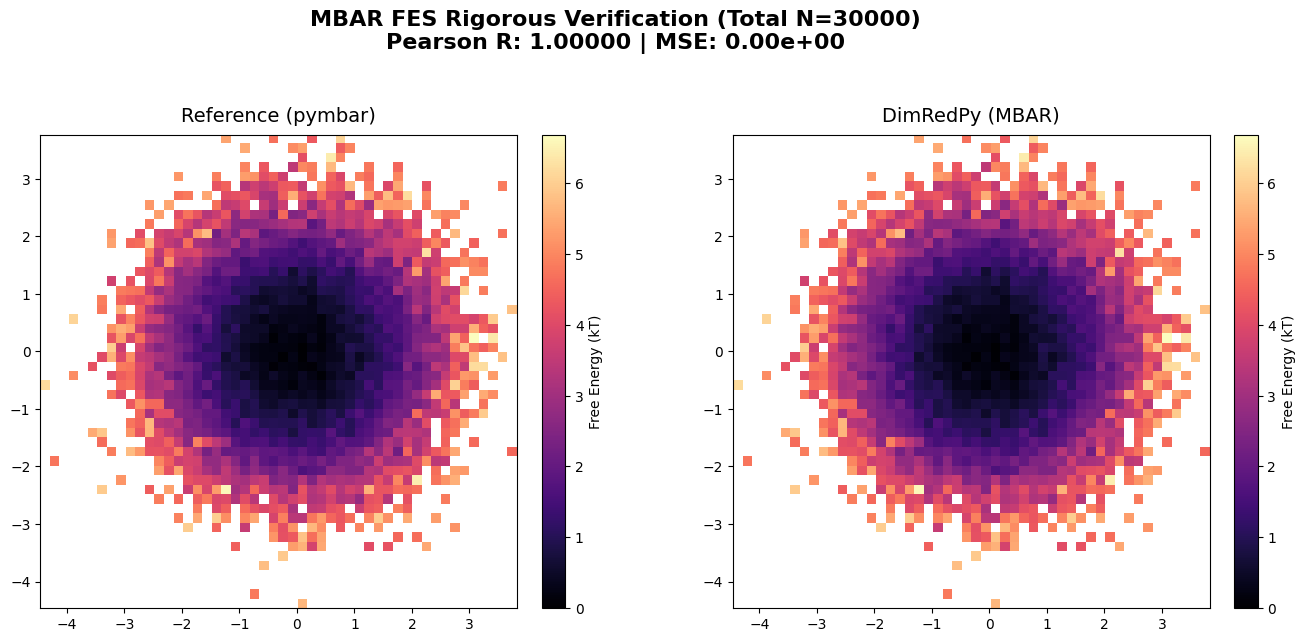

Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_mbar\mbar_rigorous_comparison.png


In [6]:
# ---------------------------------------------------------------------------
# 5. Visual Verification
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

im0 = axes[0].imshow(fe_ref.T, origin='lower', extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]), cmap='magma')
axes[0].set_title("Reference (pymbar)", fontsize=14, pad=10)
fig.colorbar(im0, ax=axes[0], label="Free Energy (kT)", fraction=0.046, pad=0.04)

im1 = axes[1].imshow(fe_dim.T, origin='lower', extent=fes_dimredpy["extent"], cmap='magma')
axes[1].set_title("DimRedPy (MBAR)", fontsize=14, pad=10)
fig.colorbar(im1, ax=axes[1], label="Free Energy (kT)", fraction=0.046, pad=0.04)

plt.suptitle(f"MBAR FES Rigorous Verification (Total N=30000)\n"
             f"Pearson R: {corr_fe:.5f} | MSE: {diff_fe_mse:.2e}", 
             fontsize=16, y=1.05, fontweight='bold')

plt.tight_layout()
out_plot = os.path.join(script_dir, "mbar_rigorous_comparison.png")
plt.savefig(out_plot, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved comparison plot to {out_plot}")